# Extracció d'entitats anomenades
Max Villalba i Biel Sánchez  
_Processament el Llenguatge Humà - GIA_
___

## Introducció

En aquesta pràctica implementarem un **reconeixedor d'entitats anomenades** utilitzant un mètode d'aprenentatge basat en atributs, els **Conditional Random Fields** (CRF).

Per començar, **importarem totes les llibreries** i **dades necessaries** per implementar l'extracció d'entitats anomenades. 

Seguidament, **prepararem les dades** i definirem una serie de **funcions** que ens ajudaran en tot el procés, i també crearem una **classe FeatureFunc** per especificar **quines característiques volem provar en el procés d'entrenament**, la qual utilitzarem com a instància del paràmetre `feature_func` de la classe **nltk.tag.CRFTagger**.

Al final, entrenarem les diferents **combinacions de codificacions** (BIO, IO, BIOW i BIOEW) amb **diferents features adddicionals** (definides sobre _FeatureFunc_) i per **cada idioma** (Espanyol i Neerlandès), per després decidir **quin és el millor model** i fer un **anàlisi dels resultats i dels errors**.

## Llibreries i dades

Començarem important i descarregant tot alló que sigui necessari per fer la pràctica:

In [19]:
%pip install python-crfsuite
import nltk
nltk.download('conll2002')
from nltk.corpus import conll2002

import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (11, 6)
from typing import Any, Dict, List, Tuple
import string
import pandas as pd

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: c:\Users\maxvi\.pyenv\pyenv-win\versions\3.12.7\python.exe -m pip install --upgrade pip
[nltk_data] Downloading package conll2002 to
[nltk_data]     C:\Users\maxvi\AppData\Roaming\nltk_data...
[nltk_data]   Package conll2002 is already up-to-date!


In [2]:
models_dir = os.path.join(os.getcwd(), 'models')
os.makedirs(models_dir, exist_ok=True)

Creem una carpeta `models` per guardar els diferents models resultants que obtindrem en l'apartat d'entrenament.

A continuació carregarem les diferents dades, les cuals provenen del **Conll Corpus**. Per a cada idioma (Espanyol i Neerlandès), obtindrem **3 conjunts de dades**:
- `_train`: dades que serviran per entrenar el model i per aprendre patrons de paraules i etiquetes.
- `_val`: conjunt de dades per calcular mètriques a partir del model entrenat i, més tard, decidir quin model o configuració és millor.
- `_test`: conjunt que s'utilitza al final per obtenir una avaluació del model final triat a partir de _val.

In [3]:
# Espanyol

esp_train = conll2002.iob_sents('esp.train')
esp_val = conll2002.iob_sents('esp.testa')
esp_test = conll2002.iob_sents('esp.testb')

In [4]:
# Neerlandés

ned_train = conll2002.iob_sents('ned.train')
ned_val = conll2002.iob_sents('ned.testa')
ned_test = conll2002.iob_sents('ned.testb')

## Funcions principals

A continuació presentem una serie de funcions que ens ajudaran a obtenir els diferents resultats adequadament:
- `prepare_data`: rep una llista de frases tokenitzades amb el format `(Paraula, POS, Tag_BIO)`. Aquesta funció simplement **elimina l'etiqueta POS** per a que nltk.tag.CRFTagger pugui llegir correctament les dades.

- `bio_to_io`, `bio_to_biow` i `bio_to_bioew`: aquestes funcions transformen una frase **de codificació BIO a codificació IO, codificació BIOW o codificació BIOEW**, respectivament.

- `convert_coding`: serveix com una espècie d'enllaç. Transforma una llista de frases **de codifició BIO a la codificació desitjada** (indicada al paràmetre `coding`).

- `evaluate`: funció que calcula les diferents **mètriques** de _precission_, _recall_ i _f1_ d'un model **basant-se en les entitats**, a partir d'un conjunt de dades proporcionat.

In [5]:
def prepare_data(sents: List[List[Tuple[str, str, str]]]) -> List[List[Tuple[str, str]]]:
    """
    Converteix una serie de frases tokenitzades eliminant l'etiqueta POS per a que 
    nltk.tag.CRFTagger pugui llegir-les correctament.

    Entrada:  
    Llista de frases, on cada frase és una llista de tuples i cada tupla és de la 
    forma (word, pos, bio).

    Sortida:  
    La mateixa llista de frases, eliminant l'etiqueta POS per a cada tupla.
    """
    return [[(word,bio) for word, pos, bio in sent] for sent in sents]

In [6]:
def bio_to_io(sentence: List[Tuple[str, str]]) -> List[Tuple[str, str]]:
    """
    Transforma una frase de codificació BIO a codificació IO, on 
    B = "inici d'una entitat", I = "dins d'una entitat" i O = "fora d'una entitat".

    Entrada:  
    Llista de tuples (és a dir, una frase) amb el format (word, bio) codificada
    en BIO.

    Sortida:  
    La mateixa frase codificada en IO.
    """
    new_sentence = []
    
    for word, tag in sentence:
        if tag.startswith("B-") or tag.startswith("I-"):
            new_tag = "I-" + tag[2:]
        else:
            new_tag = tag  # "O"
            
        new_sentence.append((word, new_tag))
    
    return new_sentence

def bio_to_biow(sentence: List[Tuple[str, str]]) -> List[Tuple[str, str]]:
    """
    Transforma una frase de codificació BIO a codificació BIOW, on 
    B = "inici d'una entitat", I = "dins d'una entitat", O = "fora d'una entitat"
    i W = "entitat d'un sol token".

    Entrada:  
    Llista de tuples (és a dir, una frase) amb el format (word, bio) codificada
    en BIO.

    Sortida:  
    La mateixa frase codificada en BIOW.
    """
    new_sentence = []
    i = 0
    n = len(sentence)
    
    while i < n:
        word, tag = sentence[i]
        
        if tag.startswith("B-"):
            entity_type = tag[2:]
            j = i + 1
            
            # trobar final de l'entitat
            while j < n and sentence[j][1] == f"I-{entity_type}":
                j += 1
            
            length = j - i
            
            if length == 1:
                new_sentence.append((word, f"W-{entity_type}"))
            else:
                new_sentence.append((word, f"B-{entity_type}"))
                for k in range(i+1, j):
                    new_sentence.append((sentence[k][0], f"I-{entity_type}"))
            
            i = j
        
        else:
            new_sentence.append((word, tag))
            i += 1
    
    return new_sentence

def bio_to_bioew(sentence: List[Tuple[str, str]]) -> List[Tuple[str, str]]:
    """
    Transforma una frase de codificació BIO a codificació BIOEW, on 
    B = "inici d'una entitat", I = "dins d'una entitat", O = "fora d'una entitat", 
    W = "entitat d'un sol token" i E = "final d'una entitat".

    Entrada:  
    Llista de tuples (és a dir, una frase) amb el format (word, bio) codificada
    en BIO.

    Sortida:  
    La mateixa frase codificada en BIOEW.
    """
    new_sentence = []
    i = 0
    n = len(sentence)
    
    while i < n:
        word, tag = sentence[i]
        
        if tag.startswith("B-"):
            entity_type = tag[2:]
            j = i + 1
            
            # trobar final de l'entitat
            while j < n and sentence[j][1] == f"I-{entity_type}":
                j += 1
            
            length = j - i
            
            if length == 1:
                new_sentence.append((word, f"W-{entity_type}"))
            else:
                # primer
                new_sentence.append((word, f"B-{entity_type}"))
                
                # mig
                for k in range(i+1, j-1):
                    new_sentence.append((sentence[k][0], f"I-{entity_type}"))
                
                # últim
                last_word = sentence[j-1][0]
                new_sentence.append((last_word, f"E-{entity_type}"))
            
            i = j
        
        else:
            new_sentence.append((word, tag))
            i += 1
    
    return new_sentence

In [7]:
def convert_coding(dataset: List[List[Tuple[str, str]]], coding: str) -> List[List[Tuple[str, str]]]:
    """
    Transforma una llista de frases a la codificació desitjada (considerant que les frases originals 
    están amb codificació BIO).

    Entrada:  
    - `dataset`: llista de frases, on cada frase és una llista de tuples i cada tupla és de la 
    forma (word, bio).
    - `coding`: codificació desitjada per transformar les frases.

    Sortida:  
    La mateixa llista de frases, transformades a la codificació indicada a `coding`.
    """
    if coding == "BIO":
        return dataset
    elif coding == "IO":
        return [bio_to_io(sent) for sent in dataset]
    elif coding == "BIOW":
        return [bio_to_biow(sent) for sent in dataset]
    elif coding == "BIOEW":
        return [bio_to_bioew(sent) for sent in dataset]
    else:
        raise ValueError(f"Coding desconegut: {coding}")

In [8]:
def evaluate(model: Any, data: List[List[Tuple[str, str]]]) -> Dict[str, float]:
    """
    Calcula diferents mètriques (_precission_, _recall_ i _f1_) per a un model 
    a partir d'un conjunt de dades. El càlcul de les mètriques es basa en les entitats,
    és a dir, considera una predicció correcta quan l'etiqueta predita coincideix amb 
    l'etiqueta real. Distingeix entre:

    - Vertaders Positius (TP): entitats predites correctament

    - Falsos Positius (FP): entitats detectades pero que no coincideixen amb l'etiqueta real.

    - Falsos Negatius (FN): entitats no detectades pel model.  

    En cas que es detecti entitat tant en la predicció com en l'etiqueta real, però amb una etiqueta 
    diferent, considerarem que es un FP (s'ha trobat una etiqueta diferent) i alhora FN (l'entitat no
    s'ha detectat de manera correcta).
    """
    tp, fp, fn = 0, 0, 0

    for sent in data:
        tokens  = [word for word, tag in sent]
        real    = [tag  for word, tag in sent]
        pred    = [tag  for word, tag in model.tag(tokens)]

        for r, p in zip(real, pred):
            r_is_entity = r != 'O'
            p_is_entity = p != 'O'

            if r_is_entity and p_is_entity:
                if r == p:
                    tp += 1   # mateixa etiqueta (ex: B-PER == B-PER)
                else:
                    fp += 1   # entitat però etiqueta diferent (ex: B-PER vs I-PER)
                    fn += 1   # l'etiqueta real no s'ha trobat correctament
            elif p_is_entity and not r_is_entity:
                fp += 1       # prediu entitat on no n'hi ha
            elif r_is_entity and not p_is_entity:
                fn += 1       # no prediu entitat on n'hi havia

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return {'precision': precision, 'recall': recall, 'f1': f1}

## Classe FeatureFunc:

Per tal de poder determinar quines característiques volem comprovar a l'entrenament, definirem la classe **FeatureFunc**. 

Aquesta classe ens permet construir de manera flexible la **funció de característiques que utilitza el model CRF** per etiquetar cada token. La idea principal és **activar o desactivar grups de features** amb paràmetres booleans, i així poder comparar diferents configuracions.

En concret, la classe inclou opcions per controlar:

- Casing: informació de **majúscules i minúscules** de la paraula actual.
- Puntuació: si la paraula està formada **únicament per signes de puntuació o si en conté**.
- Números: si la paraula està formada **únicament per dígits o si en conté**.
- Sufixos: **terminacions** de longitud 1, 2 i 3.
- Prefixos: **inicis** de longitud 1, 2 i 3.
- Longitud: **nombre de caràcters** del token.
- Context: informació del **token anterior i següent**, incloent **marques d'inici** (BOS) i **final de frase** (EOS).

Quan cridem la instància de FeatureFunc amb una frase tokenitzada i una posició concreta, el mètode \_\_call__ retorna la llista de features del token en aquella posició. Aquesta llista és exactament el format esperat per l'argument de `feature_func` de nltk.tag.CRFTagger.



In [9]:
class FeatureFunc:
    """
    Classe per especificar l'estructura de quines característiques volem provar en el procés
    d'entrenament.
    """
    def __init__(self, use_casing: bool = True, use_punct: bool = True, use_nums: bool = True, 
                 use_suffix: bool = True, use_prefix: bool = True, use_length: bool = True, 
                 use_context: bool = True) -> None:
        """
        Inicialització de la classe, on s'especifiquen totes les característiques a provar.

        Entrada:  
        Per cada un dels següents arguments, indicar amb `True` si es volen activar o `False` si no.
        Per defecte, es considera que tots els arguments s'activen (`True`):

        - `use_casing`: activa característiques de majúscules i minúscules de la paraula actual 
        (isupper: tot majúscules, istitle: la primera lletra majúsucla, islower: tot minúscules).

        - `use_punct`: activa característiques relacionades amb puntuació (ispunct: tota la paraula 
        són signes de puntuació, haspunct: conté algun signe de puntuació).

        - `use_nums`: activa característiques relacionades amb dígits (isdigit: tota la paraula són 
        dígits, hasdigit: conté algun dígit).

        - `use_suffix`: activa l'ús de sufixos de longitud 1, 2 i 3.

        - `use_prefix`: activa l'ús de prefixos de longitud 1, 2 i 3.

        - `use_length`: activa la característica de longitud de la paraula.

        - `use_context`: activa característiques de context (paraula anterior i següent, i marques 
        de principi i final de frase).
        """
        self.use_casing  = use_casing
        self.use_punct   = use_punct
        self.use_nums    = use_nums
        self.use_suffix  = use_suffix
        self.use_prefix  = use_prefix
        self.use_length  = use_length
        self.use_context = use_context

    def __call__(self, tokens: List[str], idx: int) -> List[str]:
        """
        Genera la llista de característiques per al token situat a la posició `idx`.

        Entrada:
        - `tokens`: llista de paraules de la frase.
        - `idx`: índex del token actual dins de tokens.

        Sortida:  
        Llista d'strings amb les features del token actual, preparada per ser utilitzada
        com a feature_func en nltk.tag.CRFTagger.
        """
        word = tokens[idx]

        # Paraula actual (sempre)
        features = ['word=' + word, 'lower=' + word.lower()]

        # És majúscula?
        if self.use_casing:
            features.append('isupper=%s'  % word.isupper())
            features.append('istitle=%s'  % word.istitle())
            features.append('islower=%s'  % word.islower())

        # Té signes de puntuació?
        if self.use_punct:
            features.append('ispunct=%s'   % all(c in string.punctuation for c in word))
            features.append('haspunct=%s'  % any(c in string.punctuation for c in word))

        # Té números?
        if self.use_nums:
            features.append('isdigit=%s'   % word.isdigit())
            features.append('hasdigit=%s'  % any(c.isdigit() for c in word))

        # Sufixos
        if self.use_suffix:
            features.append('suffix1=' + word[-1:])
            features.append('suffix2=' + word[-2:])
            features.append('suffix3=' + word[-3:])

        # Prefixos
        if self.use_prefix:
            features.append('prefix1=' + word[:1])
            features.append('prefix2=' + word[:2])
            features.append('prefix3=' + word[:3])

        # Longitud
        if self.use_length:
            features.append('len=%d' % len(word))

        # Context (paraula anterior i següent)
        if self.use_context:
            if idx > 0:
                prev = tokens[idx-1] # Token anterior a l'actual
                features.append('prev='        + prev.lower())
                features.append('prev_istitle=%s' % prev.istitle())
                features.append('prev_isupper=%s' % prev.isupper())
            else:
                features.append('BOS') # BOS si és el primer token (BOS = Beginning Of Sentence)
            if idx < len(tokens) - 1:
                next_ = tokens[idx+1] # Token posterior a l'actual
                features.append('next='        + next_.lower())
                features.append('next_istitle=%s' % next_.istitle())
                features.append('next_isupper=%s' % next_.isupper())
            else:
                features.append('EOS') # EOS si és l'últim token (EOS = End Of Sentence)

        return features

## Preparació de dades i features

Un cop definides totes les funcions necessaries, prepararem les dades que hem obtingut del **Conll Corpus** amb la funció de `prepare_data`:

In [10]:
esp_train_net = prepare_data(esp_train)
esp_val_net = prepare_data(esp_val)
esp_test_net = prepare_data(esp_test)
ned_train_net = prepare_data(ned_train)
ned_val_net = prepare_data(ned_val)
ned_test_net = prepare_data(ned_test)

Ara, per tal de provar diferents combinacions d'atributs, definirem els següents casos a estudiar (recordem que si no s'especifica el valor d'un parámetre es considera `True`):
- `baseline`: cas base, només ens fixarem en les **característiques relacionades amb puntuació**.
- `casing_only`: afegim al cas base les característiques relacionades amb **majúscules i minúscules**.
- `full`: considerem absolutament **totes les característiques**.
- `no_context`: considerem **totes les característiques, però sense context**.
- `preffix_suffix`: agafem el cas base, i afegim les característiques de **prefixos i sufixos**.

Aquests casos d'estudi els definirem a partir d'una instància concreta de la classe **FeatureFunc**.

In [11]:
feature_configs = [
    ('baseline',        FeatureFunc(use_casing=False, use_nums=False, use_prefix=False,
                                    use_suffix=False, use_context=False, use_length=False)),
    ('casing_only',     FeatureFunc(use_nums=False, use_prefix=False,
                                    use_suffix=False, use_context=False, use_length=False)),
    ('full',            FeatureFunc()),  # tot a True per defecte
    ('no_context',      FeatureFunc(use_context=False)),
    ('prefix_suffix',   FeatureFunc(use_casing=False, use_nums=False,
                                    use_context=False, use_length=False)),
]

## Cerca del millor model

A continuació, un cop ho tenim tot definit, procedim a entrenar tots els models per a totes les combinacions de codificacions i **feature functions** escollides. 

Per fer-ho, en la següent cel·la implementem un bucle on, per a cada codificació, entrenem cada model amb cadascun dels conjunts de **feature configs** i calculem les mètriques de precisió, **recall** i **F1**.

Hem escollit aquestes mètriques perquè ens proporcionen molta més informació que l’**accuracy**, ja que el que volem saber és, de totes les entitats anomenades, quantes estem captant correctament, evitant tant els falsos positius com els falsos negatius.

A més, també guardem cadascun dels models entrenats per tal de poder-los reutilitzar més endavant.

In [ ]:
results = []

for coding in ['BIO', 'IO', 'BIOW', 'BIOEW']: # Per cada codificació
    train_esp = convert_coding(esp_train_net, coding)
    train_ned = convert_coding(ned_train_net, coding)
    val_esp   = convert_coding(esp_val_net,   coding)
    val_ned   = convert_coding(ned_val_net,   coding)

    for feat_name, feat_func in feature_configs: # Per cada feature_config
        for lang, train, val in [('ESP', train_esp, val_esp),
                                  ('NED', train_ned, val_ned)]:

            model = nltk.tag.CRFTagger(feature_func=feat_func)
            model.train(train, os.path.join(models_dir, f'crf_{coding}_{feat_name}_{lang}.mdl')) # Guardem el model

            metrics = evaluate(model, val) # Evaluem el model
            print(f"{coding} | {feat_name} | {lang} => "
                  f"P={metrics['precision']:.4f} "
                  f"R={metrics['recall']:.4f} "
                  f"F1={metrics['f1']:.4f}")
            results.append({'coding': coding, 'features': feat_name,
                            'lang': lang, **metrics})

df = pd.DataFrame(results)
print(df.pivot_table(index=['coding', 'features'], columns='lang', values='f1'))

BIO | baseline | ESP => P=0.7571 R=0.4491 F1=0.5637
BIO | baseline | NED => P=0.8536 R=0.3061 F1=0.4507
BIO | casing_only | ESP => P=0.6517 R=0.6701 F1=0.6608
BIO | casing_only | NED => P=0.6502 R=0.5967 F1=0.6223
BIO | full | ESP => P=0.7748 R=0.7560 F1=0.7653
BIO | full | NED => P=0.7680 R=0.7254 F1=0.7461
BIO | no_context | ESP => P=0.7255 R=0.7202 F1=0.7229
BIO | no_context | NED => P=0.7434 R=0.7011 F1=0.7216
BIO | prefix_suffix | ESP => P=0.7209 R=0.7152 F1=0.7181
BIO | prefix_suffix | NED => P=0.7452 R=0.6820 F1=0.7122
IO | baseline | ESP => P=0.7244 R=0.4276 F1=0.5378
IO | baseline | NED => P=0.8185 R=0.2986 F1=0.4376
IO | casing_only | ESP => P=0.6592 R=0.6627 F1=0.6610
IO | casing_only | NED => P=0.6722 R=0.6222 F1=0.6463
IO | full | ESP => P=0.7776 R=0.7584 F1=0.7679
IO | full | NED => P=0.7767 R=0.7342 F1=0.7549
IO | no_context | ESP => P=0.7116 R=0.7108 F1=0.7112
IO | no_context | NED => P=0.7387 R=0.6879 F1=0.7124
IO | prefix_suffix | ESP => P=0.7161 R=0.7102 F1=0.7131
IO

A continuació, definim una funció que ens permet recuperar un model ja entrenat, de manera que no sigui necessari tornar-lo a entrenar o carregar manualment en noves sessions.

In [13]:
# Preparar mètriques sense reentrenar: carrega la memòria cau si existeix, si no avalua els models ja guardats.
required_symbols = ['feature_configs', 'convert_coding', 'evaluate', 'models_dir']
missing = [s for s in required_symbols if s not in globals()]
if missing:
    raise RuntimeError(
        f"Falten definicions en memòria: {missing}. Executa primer les cel·les 1-12."
    )

val_cache_path = os.path.join(models_dir, 'metrics_val.csv')
final_cache_path = os.path.join(models_dir, 'metrics_final.csv')

if 'df' not in globals():
    if os.path.exists(val_cache_path):
        df = pd.read_csv(val_cache_path)
        print(f"df carregat des de memòria cau: {val_cache_path}")
    else:
        records = []
        data_by_lang = {
            'ESP': {'val': esp_val_net},
            'NED': {'val': ned_val_net},
        }

        for coding in ['BIO', 'IO', 'BIOW', 'BIOEW']:
            for feat_name, feat_func in feature_configs:
                for lang in ['ESP', 'NED']:
                    model_path = os.path.join(models_dir, f'crf_{coding}_{feat_name}_{lang}.mdl')
                    if not os.path.exists(model_path):
                        continue

                    model = nltk.tag.CRFTagger(feature_func=feat_func)
                    model.set_model_file(model_path)
                    val_data = convert_coding(data_by_lang[lang]['val'], coding)
                    metrics = evaluate(model, val_data)
                    records.append({'coding': coding, 'features': feat_name, 'lang': lang, **metrics})

        df = pd.DataFrame(records)
        if df.empty:
            raise RuntimeError('No s\'han pogut carregar models .mdl per construir df.')
        df.to_csv(val_cache_path, index=False)
        print(f"df reconstruït a partir dels models i guardat a: {val_cache_path}")

if 'final_df' not in globals():
    if os.path.exists(final_cache_path):
        final_df = pd.read_csv(final_cache_path)
        print(f"final_df carregat des de memòria cau: {final_cache_path}")
    else:
        final_results = []
        data_by_lang = {
            'ESP': {'test': esp_test_net},
            'NED': {'test': ned_test_net},
        }

        for lang in ['ESP', 'NED']:
            best = df[df['lang'] == lang].sort_values('f1', ascending=False).iloc[0]
            coding = best['coding']
            feat_name = best['features']
            feat_func = dict(feature_configs)[feat_name]

            model_path = os.path.join(models_dir, f'crf_{coding}_{feat_name}_{lang}.mdl')
            model = nltk.tag.CRFTagger(feature_func=feat_func)
            model.set_model_file(model_path)

            test_data = convert_coding(data_by_lang[lang]['test'], coding)
            test_metrics = evaluate(model, test_data)

            final_results.append({
                'lang': lang,
                'coding': coding,
                'features': feat_name,
                'val_f1': best['f1'],
                'test_f1': test_metrics['f1'],
                'val_precision': best['precision'],
                'test_precision': test_metrics['precision'],
                'val_recall': best['recall'],
                'test_recall': test_metrics['recall'],
            })

        final_df = pd.DataFrame(final_results)
        final_df.to_csv(final_cache_path, index=False)
        print(f"final_df reconstruït i guardat a: {final_cache_path}")

print('Llest: df i final_df disponibles sense reentrenar.')

df carregat des de memòria cau: c:\Users\maxvi\OneDrive\Escriptori\Uni\4t Quadri\PLH\Practica3\models\metrics_val.csv
final_df carregat des de memòria cau: c:\Users\maxvi\OneDrive\Escriptori\Uni\4t Quadri\PLH\Practica3\models\metrics_final.csv
Llest: df i final_df disponibles sense reentrenar.


## Anàlisi de resultats

A continuació, farem una anàlisi dels resultats per tal d’entendre quin és el model que hem obtingut i el perquè.

El primer que observem és que tant per a espanyol com per a neerlandès obtenim el mateix model: la codificació IO amb totes les **feature functions**. Això ens indica que és preferible un model més senzill, ja que la codificació IO presenta menys etiquetes i és més fàcil de gestionar.

Tot i això, si ens fixem en els resultats, veiem que totes les codificacions presenten valors molt similars quan s’utilitzen les mateixes **feature functions**. Per tant, podem deduir que la codificació no és un factor tan diferencial, sinó que el que realment té més pes són les **feature functions**.

Pel que fa a aquestes, podem observar que com més informació proporcionen, millor es comporta el model. Això és lògic, ja que com més informació tenim, més informades són les decisions i, per tant, més probabilitat hi ha que siguin correctes.

El que falta avaluar és si el model presenta **overfitting**, ja que podria ocórrer si fem servir una gran quantitat de **feature functions**. La següent cel·la avalua els models amb el conjunt de test i, a continuació, farem la comparació amb el conjunt de validació.

In [14]:
for _, row in final_df.iterrows():
    lang = row['lang']
    coding = row['coding']
    feat_name = row['features']

    print(f"\nMillor configuració per {lang}: coding={coding}, features={feat_name}")

    print(f"Resultats en TEST per {lang}: "
          f"P={row['test_precision']:.4f} "
          f"R={row['test_recall']:.4f} "
          f"F1={row['test_f1']:.4f}")


Millor configuració per ESP: coding=IO, features=full
Resultats en TEST per ESP: P=0.8062 R=0.7852 F1=0.7956

Millor configuració per NED: coding=IO, features=full
Resultats en TEST per NED: P=0.7773 R=0.7405 F1=0.7584


### Anàlisi d'Overfitting

Tal com podem observar, el conjunt de test obté resultats molt similars al conjunt de validació i, fins i tot, són lleugerament millors. Això ens indica que el model no presenta **overfitting** i, per tant, queda validat.

A continuació, veurem una anàlisi visual i passarem a fer una anàlisi dels errors.

In [ ]:
print("\nComparació VAL vs TEST:")

for _, row in final_df.iterrows():
    print(f"\nMillor configuració per {row['lang']}: "
          f"coding={row['coding']}, features={row['features']}")

    print(f"VALIDACIÓ {row['lang']}: "
          f"P={row['val_precision']:.4f} "
          f"R={row['val_recall']:.4f} "
          f"F1={row['val_f1']:.4f}")

    print(f"TEST {row['lang']}: "
          f"P={row['test_precision']:.4f} "
          f"R={row['test_recall']:.4f} "
          f"F1={row['test_f1']:.4f}")

print("\nTaula final:")
print(final_df)


Comparació VAL vs TEST:

Millor configuració per ESP: coding=IO, features=full
VALIDACIÓ ESP: P=0.7776 R=0.7584 F1=0.7679
TEST ESP: P=0.8062 R=0.7852 F1=0.7956

Millor configuració per NED: coding=IO, features=full
VALIDACIÓ NED: P=0.7767 R=0.7342 F1=0.7549
TEST NED: P=0.7773 R=0.7405 F1=0.7584

Taula final:
  lang coding features    val_f1   test_f1  val_precision  test_precision  \
0  ESP     IO     full  0.767913  0.795572       0.777642        0.806216   
1  NED     IO     full  0.754879  0.758449       0.776702        0.777251   

   val_recall  test_recall  
0    0.758425     0.785206  
1    0.734249     0.740535  


### Heatmaps

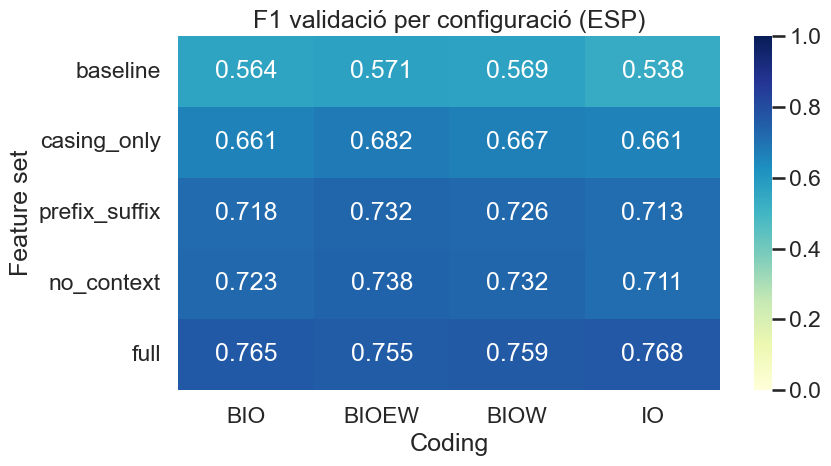

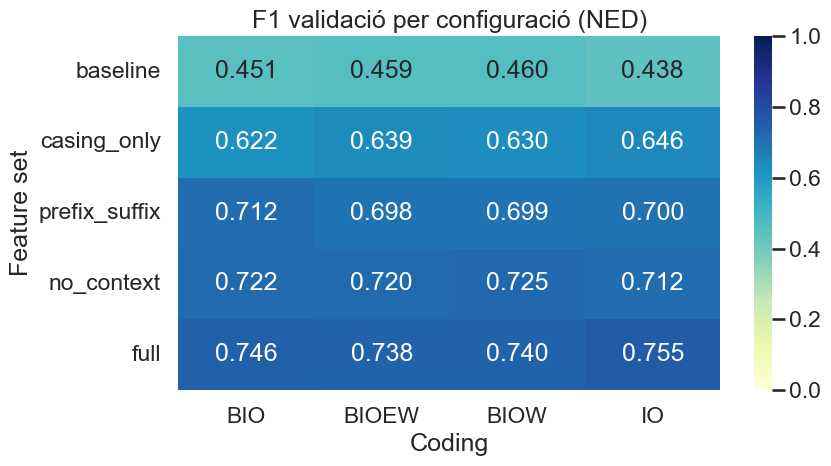

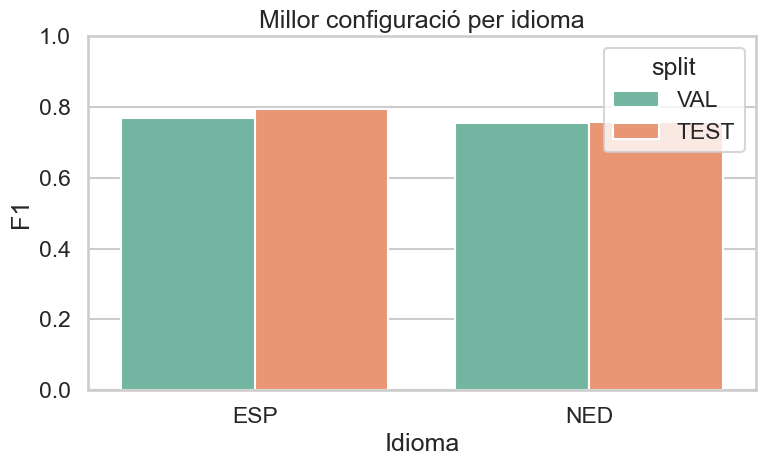

In [ ]:
for lang in ['ESP', 'NED']:
    pivot = (
        df[df['lang'] == lang]
        .pivot_table(index='features', columns='coding', values='f1', aggfunc='mean')
        .reindex(index=['baseline', 'casing_only', 'prefix_suffix', 'no_context', 'full'])
    )

    plt.figure(figsize=(9, 5))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu', vmin=0, vmax=1)
    plt.title(f'F1 validació per configuració ({lang})')
    plt.xlabel('Coding')
    plt.ylabel('Feature set')
    plt.tight_layout()
    plt.show()

# 2) Comparació VAL vs TEST per la millor config de cada idioma
plot_df = final_df.melt(
    id_vars=['lang', 'coding', 'features'],
    value_vars=['val_f1', 'test_f1'],
    var_name='split',
    value_name='f1'
)
plot_df['split'] = plot_df['split'].map({'val_f1': 'VAL', 'test_f1': 'TEST'})

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x='lang', y='f1', hue='split', palette='Set2')
plt.title('Millor configuració per idioma')
plt.ylim(0, 1)
plt.xlabel('Idioma')
plt.ylabel('F1')
plt.tight_layout()
plt.show()

Aquí veiem més en detall i de manera més visual com es comporta cada codificació segons les **feature functions** escollides. Veiem clarament, als **heatmaps**, que a mesura que anem afegint **feature functions**, el valor de F1 augmenta de manera molt similar per a totes les codificacions, fins arribar a fer-les servir totes, moment en què obtenim el valor màxim de F1.  

També veiem una comparativa per idioma, on l’espanyol sembla obtenir millors resultats que el neerlandès, tot i que la diferència és tan petita que gairebé és zero.

## Anàlisi d'errors

## Funcions

A continuació presentem una sèrie de funcions que ens ajudaran a fer aquesta anàlisi:

- `get_confusions`: rep un model CRF i una llista de frases tokenitzades amb el format `(Paraula, Tag_BIO)`. Aquesta funció **compta les confusions entre etiquetes verdaderes i prediccions**, retornant un `Counter` amb els parells `(veritable, predicció)`.

- `strip_prefix`: rep una etiqueta que pot tenir prefixos `B-`, `I-`, `E-` o `W-` i **elimina el prefix**, deixant només el tipus d’entitat. Manté `O` tal qual.

- `entity_level_errors`: rep un model CRF i una llista de frases tokenitzades `(Paraula, Tag_BIO)`. Calcula els **errors i totals per cada tipus d’entitat** a nivell de token, ignorants els prefixos B/I/E/W, retornant dos `defaultdict` amb els comptadors d’errors i totals.

In [24]:
from typing import List, Tuple, DefaultDict
from collections import Counter, defaultdict
import nltk


def get_confusions(model: nltk.tag.CRFTagger, 
                   data: List[List[Tuple[str, str]]]
                  ) -> Counter[Tuple[str, str]]:
    """
    Calcula les confusions entre etiquetes verdaderes i prediccions.

    Args:
        model: Model CRF entrenat (nltk.tag.CRFTagger).
        data: Llista de frases, on cada frase és una llista de tuples (token, etiqueta veritable).

    Returns:
        Counter amb parells (etiqueta_veritable, etiqueta_predicha) com a clau i nombre d'ocurrències com a valor.
    """
    confusions: Counter[Tuple[str, str]] = Counter()

    for sent in data:
        tokens = [w for w, t in sent]
        true_tags = [t for w, t in sent]
        pred_tags = [t for w, t in model.tag(tokens)]

        for t_true, t_pred in zip(true_tags, pred_tags):
            if t_true != t_pred:
                confusions[(t_true, t_pred)] += 1

    return confusions


def strip_prefix(tag: str) -> str:
    """
    Elimina el prefix B-, I-, E-, W- d'una etiqueta, deixant només el tipus d'entitat.
    Manté 'O' tal qual.

    Args:
        tag: Etiqueta amb o sense prefix.

    Returns:
        Etiqueta sense prefix (tipus d'entitat o 'O').
    """
    if tag == 'O':
        return 'O'
    return tag.split('-')[-1]


def entity_level_errors(model: nltk.tag.CRFTagger, 
                        data: List[List[Tuple[str, str]]]
                       ) -> Tuple[DefaultDict[str, int], DefaultDict[str, int]]:
    """
    Calcula errors i totals per entitat a nivell de token, ignorants els prefixes B/I/E/W.

    Args:
        model: Model CRF entrenat (nltk.tag.CRFTagger).
        data: Llista de frases, on cada frase és una llista de tuples (token, etiqueta veritable).

    Returns:
        errors: DefaultDict amb nombre de prediccions incorrectes per cada tipus d'entitat.
        totals: DefaultDict amb nombre total d'ocurrències per cada tipus d'entitat.
    """
    errors: DefaultDict[str, int] = defaultdict(int)
    totals: DefaultDict[str, int] = defaultdict(int)

    for sent in data:
        tokens = [w for w, t in sent]
        true_tags = [strip_prefix(t) for w, t in sent]
        pred_tags = [strip_prefix(t) for w, t in model.tag(tokens)]

        for t_true, t_pred in zip(true_tags, pred_tags):
            totals[t_true] += 1
            if t_true != t_pred:
                errors[t_true] += 1

    return errors, totals

### Exemples

In [ ]:
def show_errors(model, data, max_sent=5):
    shown = 0

    for sent in data:
        tokens = [w for w, t in sent]
        true_tags = [t for w, t in sent]
        pred = model.tag(tokens)
        pred_tags = [t for w, t in pred]

        if true_tags != pred_tags:
            print("\nFrase:")
            print(" ".join(tokens))

            print("\nTRUE:")
            print(true_tags)

            print("\nPRED:")
            print(pred_tags)

            shown += 1
            if shown >= max_sent:
                break

show_errors(model, test_data, max_sent=5)


Frase:
Las reservas " on line " de billetes aéreos a través de Internet aumentaron en España un 300 por ciento en el primer trimestre de este año con respecto al mismo período de 1999 , aseguró hoy Iñigo García Aranda , responsable de comunicación de Savia Amadeus .

TRUE:
['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'I-MISC', 'O', 'O', 'I-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'I-PER', 'I-PER', 'I-PER', 'O', 'O', 'O', 'O', 'O', 'I-ORG', 'I-ORG', 'O']

PRED:
['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'I-MISC', 'O', 'O', 'I-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'I-PER', 'I-PER', 'I-PER', 'O', 'O', 'O', 'O', 'O', 'I-LOC', 'I-LOC', 'O']

Frase:
García Aranda presentó a la prensa el sistema Amadeus , que utilizan la mayor parte de las agencias de viajes españolas para reservar billetes de avión o tren , así como 

En aquesta sortida podem veure alguns exemples on el model s'equivoca per tal d'entendre millor els errors i veure quan són més freqüents. Ho fem només en espanyol, ja que no coneixem el neerlandès i no podríem interpretar correctament el text.  

El primer que notem és que el model tendeix a fallar amb entitats poc comunes, com per exemple "Savia Amadeus", que és una organització però que pel nom pot semblar un nom propi. També veiem casos on una entitat `I-MISC` es marca com a `O`. Això és comprensible, ja que les entitats `MISC` poden incloure molts tipus diferents d’elements, amb poc en comú, i això dificulta que el model les detecti correctament.  

Altres patrons que s’observen:  
- Errors quan hi ha noms compostos de persones o organitzacions, on el model confon part del nom amb un altre tipus d’entitat.  
- Confusions entre persones (`PER`) i organitzacions (`ORG`) quan apareixen juntes en la mateixa frase.  
- Alguns errors a les fronteres d’entitat, especialment en noms llargs o frases complexes, on el model no marca correctament l’inici o final de l’etiqueta.  

Malgrat aquests errors, el model funciona bé amb entitats habituals i clares, com noms propis simples o organitzacions conegudes. Aquesta anàlisi ens ajuda a **identificar on caldria millorar**: afegir més exemples d’entitats rares, refinar les *feature functions*, o ajustar la codificació per a entitats compostes.

### Errors més comuns

C:\Users\maxvi\AppData\Local\Temp\ipykernel_21800\128521272.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_conf, y='confusion', x='count', palette='mako')


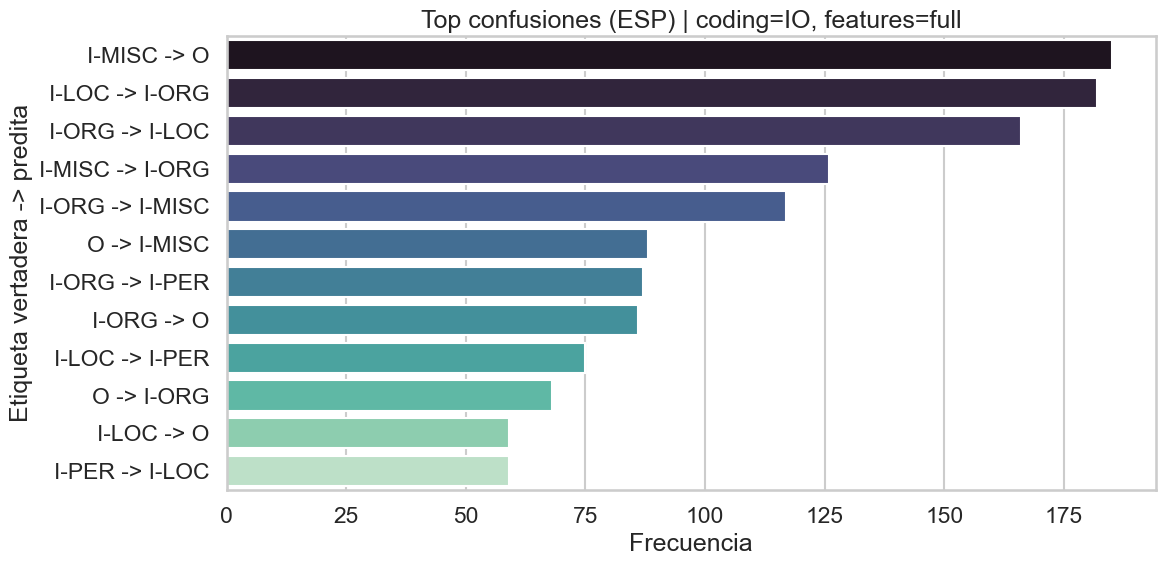

C:\Users\maxvi\AppData\Local\Temp\ipykernel_21800\128521272.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_conf, y='confusion', x='count', palette='mako')


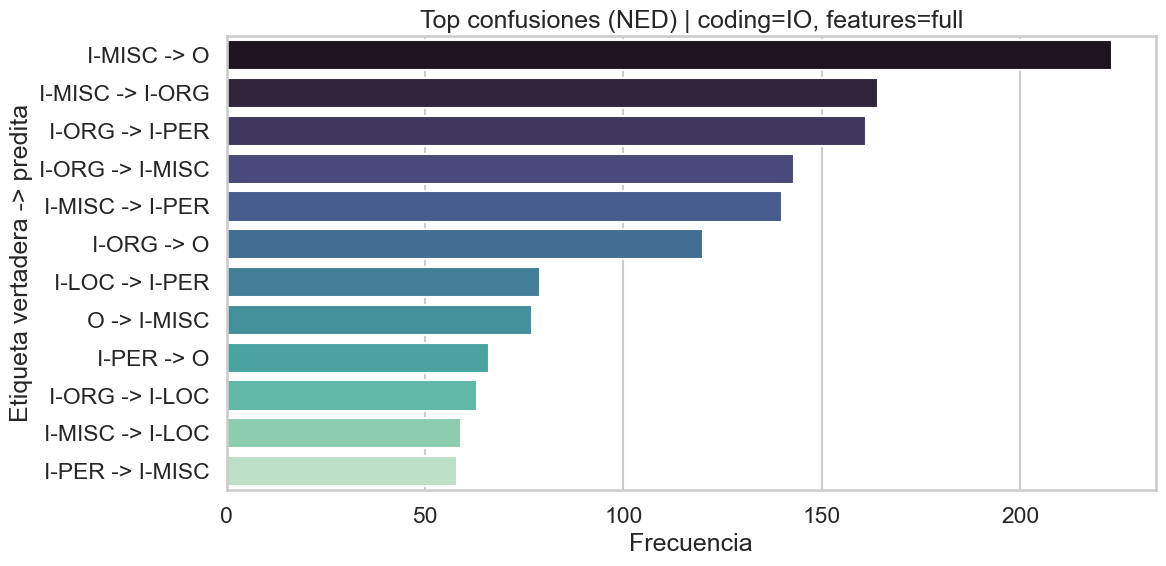

In [32]:
# Diccionari per guardar els models carregats
loaded_models = {}

for lang in ['ESP', 'NED']:
    best = df[df['lang'] == lang].sort_values('f1', ascending=False).iloc[0]
    coding = best['coding']
    feat_name = best['features']
    feat_func = dict(feature_configs)[feat_name]

    if lang not in loaded_models:
        model_path = os.path.join(models_dir, f"crf_{coding}_{feat_name}_{lang}.mdl")
        model = nltk.tag.CRFTagger(feature_func=feat_func)
        model.set_model_file(model_path)
        loaded_models[lang] = model
    else:
        model = loaded_models[lang]

    test_data = convert_coding(esp_test_net if lang == 'ESP' else ned_test_net, coding)

    # Confusions
    conf_lang = get_confusions(model, test_data)
    top_conf = pd.DataFrame(
        [(f'{t} -> {p}', c) for (t, p), c in conf_lang.most_common(12)],
        columns=['confusion', 'count']
    )

    # Gràfic
    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_conf, y='confusion', x='count', palette='mako')
    plt.title(f'Top confusiones ({lang}) | coding={coding}, features={feat_name}')
    plt.xlabel('Frecuencia')
    plt.ylabel('Etiqueta vertadera -> predita')
    plt.tight_layout()
    plt.show()

En aquests dos gràfics podem veure quins són els errors més comuns que comet el model. En general, els patrons d’error són bastant similars entre els dos idiomes i coincideixen amb els que hem observat anteriorment.  

El més destacable és que hi ha una gran quantitat d’errors amb la categoria `MISC`. Com hem mencionat abans, aquesta categoria funciona com un “sac” on s’inclou tot el que no pertany a altres categories, i per això és difícil identificar patrons consistents entre els seus elements. L’error més comú és marcar entitats `MISC` com a `O`.  

També es nota que el model espanyol té més dificultat a diferenciar organitzacions (`ORG`) de localitzacions (`LOC`). Això és comprensible, ja que moltes organitzacions inclouen noms geogràfics o localitzacions dins del seu nom, generant confusió quan el context no és suficient per distingir-les.

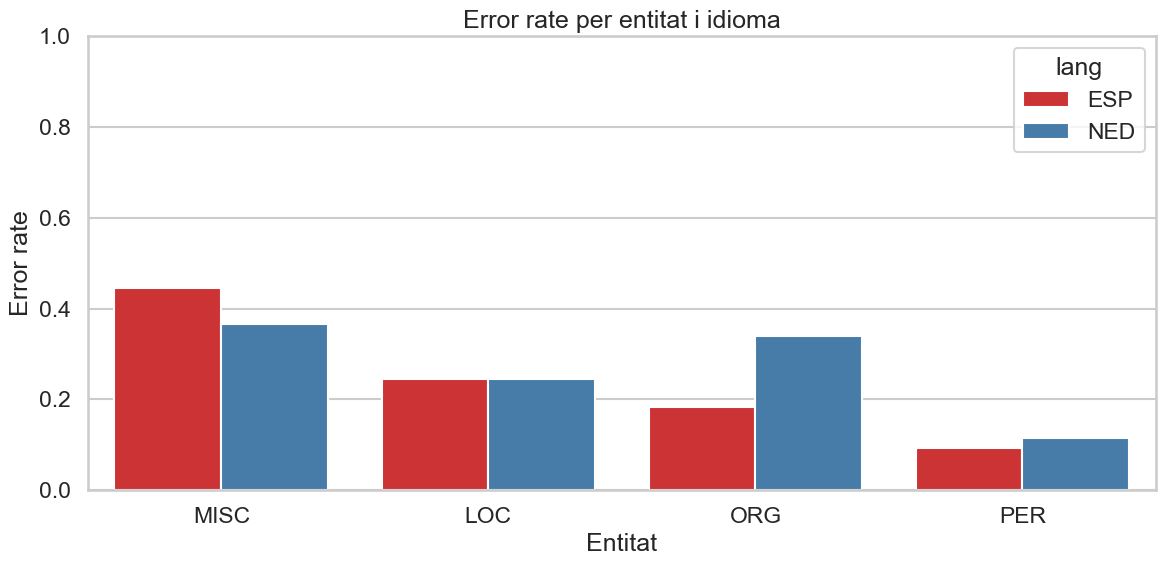

In [36]:
entity_rows = []

for lang in ['ESP', 'NED']:
    best = df[df['lang'] == lang].sort_values('f1', ascending=False).iloc[0]
    coding = best['coding']
    feat_name = best['features']
    feat_func = dict(feature_configs)[feat_name]

    if lang not in loaded_models:
        model_path = os.path.join(models_dir, f"crf_{coding}_{feat_name}_{lang}.mdl")
        model = nltk.tag.CRFTagger(feature_func=feat_func)
        model.set_model_file(model_path)
        loaded_models[lang] = model
    else:
        model = loaded_models[lang]

    test_data = convert_coding(esp_test_net if lang == 'ESP' else ned_test_net, coding)

    errors_lang, totals_lang = entity_level_errors(model, test_data)

    for ent, total in totals_lang.items():
        if ent == 'O' or total == 0:
            continue
        entity_rows.append({
            'lang': lang,
            'entity': ent,
            'error_rate': errors_lang[ent] / total,
            'count': total
        })

# DataFrame i gràfic
entity_df = pd.DataFrame(entity_rows).sort_values(['lang', 'error_rate'], ascending=[True, False])

plt.figure(figsize=(12, 6))
sns.barplot(data=entity_df, x='entity', y='error_rate', hue='lang', palette='Set1')
plt.title('Error rate per entitat i idioma')
plt.xlabel('Entitat')
plt.ylabel('Error rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


Aquí podem veure en detall la quantitat d’errors per categoria. Com ja hem mencionat abans, la categoria que presenta més errors és `MISC`, tot i que el model espanyol sembla tenir-ne més que el neerlandès.

A continuació, la següent categoria amb més errors és `LOC`, on ambdós idiomes presenten una quantitat similar d’errors. Els errors en localitzacions es deuen principalment a noms amb context ambigu o que poden formar part de noms d’organitzacions o persones.  

Pel que fa a `ORG`, el model neerlandès presenta aproximadament el doble d’errors que l’espanyol, com ja es podia observar al gràfic anterior. Això podria ser degut a una menor representació d’organitzacions en el corpus neerlandès o a noms més complexos que generen confusions amb `LOC`.  

Finalment, la categoria amb menys errors és `PER`, mostrant que el model és més consistent detectant persones. Això té sentit, ja que els noms propis solen aparèixer en contextos més clars i són més fàcilment aprenibles pel model.

### Errors per longitud de frase

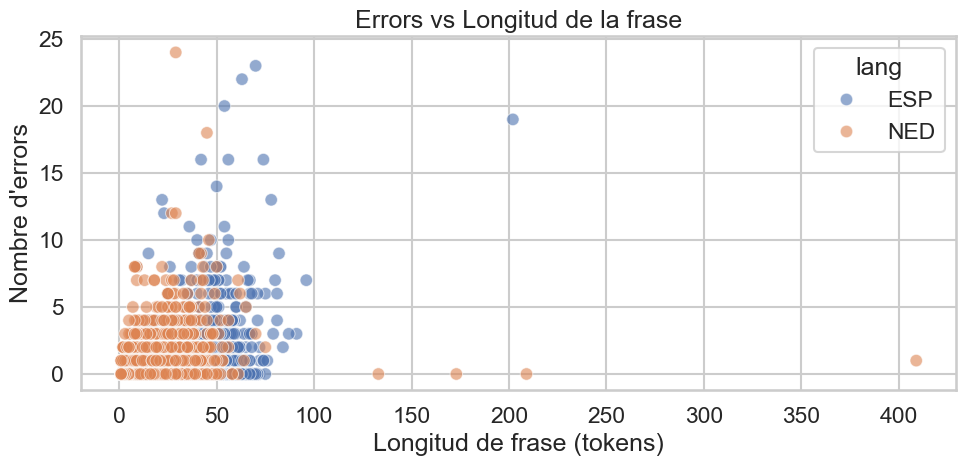

In [ ]:
length_errors = []

for lang in ['ESP', 'NED']:
    model = loaded_models[lang]
    test_data = convert_coding(esp_test_net if lang=='ESP' else ned_test_net, df[df['lang']==lang].sort_values('f1', ascending=False).iloc[0]['coding'])
    
    for sent in test_data:
        length = len(sent)
        true_tags = [strip_prefix(t) for w, t in sent]
        pred_tags = [strip_prefix(t) for w, t in model.tag([w for w,t in sent])]
        errors = sum(t1 != t2 for t1, t2 in zip(true_tags, pred_tags))
        length_errors.append({'lang': lang, 'length': length, 'errors': errors})

length_df = pd.DataFrame(length_errors)
# Opcional: plot errors vs longitud
plt.figure(figsize=(10,5))
sns.scatterplot(data=length_df, x='length', y='errors', hue='lang', alpha=0.6)
plt.title("Errors vs Longitud de la frase")
plt.xlabel("Longitud de frase (tokens)")
plt.ylabel("Nombre d'errors")
plt.tight_layout()
plt.show()

En aquest gràfic veiem clarament que la majoria dels errors es concentren en les frases més curtes.  

A mesura que la longitud de les frases augmenta, la quantitat d’errors decreix de manera notable. Per a les frases amb menys de 75 tokens, els errors apareixen amb més freqüència.  

Cal tenir en compte que aquest efecte es veu accentuat perquè la majoria de frases del conjunt de test són curtes, fet que provoca que la major part dels punts s’agrupin a l’esquerra del gràfic. Tot i així, el patró indica que el model tendeix a cometre més errors en frases breus, probablement degut a la manca de context suficient per identificar correctament les entitats.

### Errors segons posició

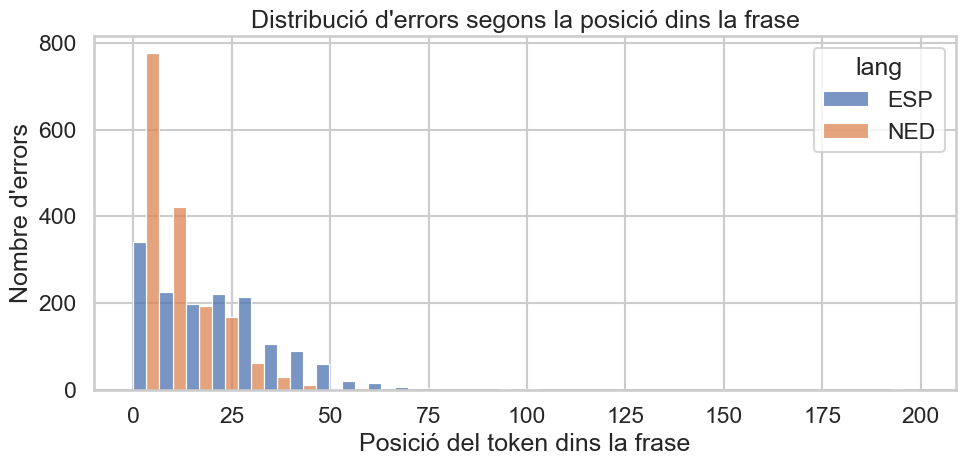

In [ ]:
position_errors = []

for lang in ['ESP', 'NED']:
    model = loaded_models[lang]
    test_data = convert_coding(esp_test_net if lang=='ESP' else ned_test_net,
                               df[df['lang']==lang].sort_values('f1', ascending=False).iloc[0]['coding'])
    
    for sent in test_data:
        true_tags = [strip_prefix(t) for w, t in sent]
        pred_tags = [strip_prefix(t) for w, t in model.tag([w for w,t in sent])]
        for i, (t_true, t_pred) in enumerate(zip(true_tags, pred_tags)):
            if t_true != t_pred:
                position_errors.append({'lang': lang, 'position': i, 'error': 1})
                
position_df = pd.DataFrame(position_errors)
plt.figure(figsize=(10,5))
sns.histplot(data=position_df, x='position', hue='lang', multiple='dodge', bins=30)
plt.title("Distribució d'errors segons la posició dins la frase")
plt.xlabel("Posició del token dins la frase")
plt.ylabel("Nombre d'errors")
plt.tight_layout()
plt.show()

En aquesta gràfica veiem un efecte similar al de l’anterior: com més aviat apareix una entitat dins la frase, més alta és la probabilitat que estigui mal classificada.  

Tot i que passa el mateix que amb l’anàlisi de longitud, aquí es veu clarament que a mesura que la posició del token dins la frase augmenta, la quantitat d’errors disminueix.  

Això es deu al fet que els tokens al principi de la frase sovint tenen menys context disponible per al model, cosa que dificulta la identificació correcta de l’entitat. En canvi, quan l’entitat apareix més cap al final de la frase, el context anterior ajuda el model a fer prediccions més precises.  

## Conclusió

Durant aquesta pràctica hem explorat com les diferents combinacions de codificacions (IO, BIO, BIOW, BIOEW) i les *feature functions* poden influir en el rendiment d’un model de **Conditional Random Fields (CRF)** per a la detecció d’entitats anomenades. Hem provat diverses combinacions per identificar quines configuracions donen millors resultats i quines menys efectives, i hem observat que, en general, el millor rendiment s’aconsegueix amb una codificació simple combinada amb un context més ampli.

A més, hem analitzat els resultats per detectar possibles problemes de **overfitting** i assegurar que els models seleccionats generalitzen correctament sobre el conjunt de test. Finalment, hem dut a terme un **anàlisi detallat dels errors**, identificant patrons freqüents i comprenent per què i on el model cometia equivocacions. Aquesta anàlisi ens permetrà orientar futures millores, com ajustar les *feature functions*, augmentar la cobertura de certs tipus d’entitats o treballar millor les frases curtes i amb menys context.